# COMP34812 — EDA

Each track takes two text inputs and predicts a binary label (0 or 1).
1. **Track A — NLI** (Natural Language Inference)
2. **Track B — ED** (Evidence Detection)
3. **Track C — AV** (Authorship Verification)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# word overlap between two texts
def word_overlap(t1, t2):
    s1, s2 = set(str(t1).lower().split()), set(str(t2).lower().split())
    return len(s1 & s2) / len(s1 | s2) if s1 | s2 else 0.0

# quick dataset summary
def summarise(df, col1, col2):
    print(f"Rows: {len(df):,}")
    print(f"Label balance: {df['label'].value_counts().to_dict()}  ({df['label'].mean():.1%} positive)")
    print(f"Avg {col1} length: {df[col1].str.len().mean():.0f} chars / {df[col1].str.split().str.len().mean():.1f} words")
    print(f"Avg {col2} length: {df[col2].str.len().mean():.0f} chars / {df[col2].str.split().str.len().mean():.1f} words")

---
## Track A — Natural Language Inference (NLI)

### What is NLI? (ai slop answer)

**Natural Language Inference** is the task of determining the logical relationship between two sentences:
- A **premise** — a statement describing some situation
- A **hypothesis** — a second statement that may or may not follow from the premise

The model must predict whether the hypothesis is **entailed** (label = 1) or **not entailed** (label = 0) by the premise.

**Example:**
- Premise: *"A man is playing guitar on stage."*
- Hypothesis: *"A musician is performing."* → **Label 1** (entailed)
- Hypothesis: *"A man is sleeping at home."* → **Label 0** (not entailed)

NLI is one of the most well-studied tasks in NLU. It requires understanding synonymy, negation, quantifiers, and world knowledge. Pre-trained models like BERT were partly trained on NLI data (MNLI), so transformers tend to do very well here.

In [3]:
# Load NLI data
nli_train = pd.read_csv("../data/training_data/NLI/train.csv")
nli_dev   = pd.read_csv("../data/training_data/NLI/dev.csv")
nli_trial = pd.read_csv("../data/trial_data/NLI_trial.csv")

print("=== NLI Training Set ===")
summarise(nli_train, "premise", "hypothesis")
print(f"\n=== NLI Dev Set ===")
summarise(nli_dev, "premise", "hypothesis")

=== NLI Training Set ===
Rows: 24,432
Label balance: {1: 12648, 0: 11784}  (51.8% positive)
Avg premise length: 109 chars / 18.9 words
Avg hypothesis length: 60 chars / 10.4 words

=== NLI Dev Set ===
Rows: 6,736
Label balance: {1: 3478, 0: 3258}  (51.6% positive)
Avg premise length: 108 chars / 18.6 words
Avg hypothesis length: 60 chars / 10.4 words


In [4]:
# some examples from each label
print("--- Label 0 (Not Entailed) ---")
for _, row in nli_train[nli_train["label"] == 0].head(3).iterrows():
    print(f"  Premise:    {row['premise'][:120]}")
    print(f"  Hypothesis: {row['hypothesis'][:120]}")
    print()

print("--- Label 1 (Entailed) ---")
for _, row in nli_train[nli_train["label"] == 1].head(3).iterrows():
    print(f"  Premise:    {row['premise'][:120]}")
    print(f"  Hypothesis: {row['hypothesis'][:120]}")
    print()

--- Label 0 (Not Entailed) ---
  Premise:    The summary rating levels include achieved results, minimally satisfactory, and unsatisfactory.
  Hypothesis: The rating level of exceptional was reserved for the best performances.

  Premise:    If we ever prove that George W. Bush has lied to us at our expense, then this will be a factor that should be weighed in
  Hypothesis: George W. Bush is the name of Obama's pet ferret.

  Premise:    Astley Priors was a pleasant red-brick edifice, surrounded by well-wooded grounds which effectually shielded the house f
  Hypothesis: Astley Priors was a modern high-rise in the center of the city. 

--- Label 1 (Entailed) ---
  Premise:    yeah i don't know cut California in half or something
  Hypothesis: Yeah. I'm not sure how to make that fit. Maybe you could cut California in half or just resize it to make it fit.

  Premise:    actual names will not be used
  Hypothesis: For the sake of privacy, actual names are not used.

  Premise:    The film

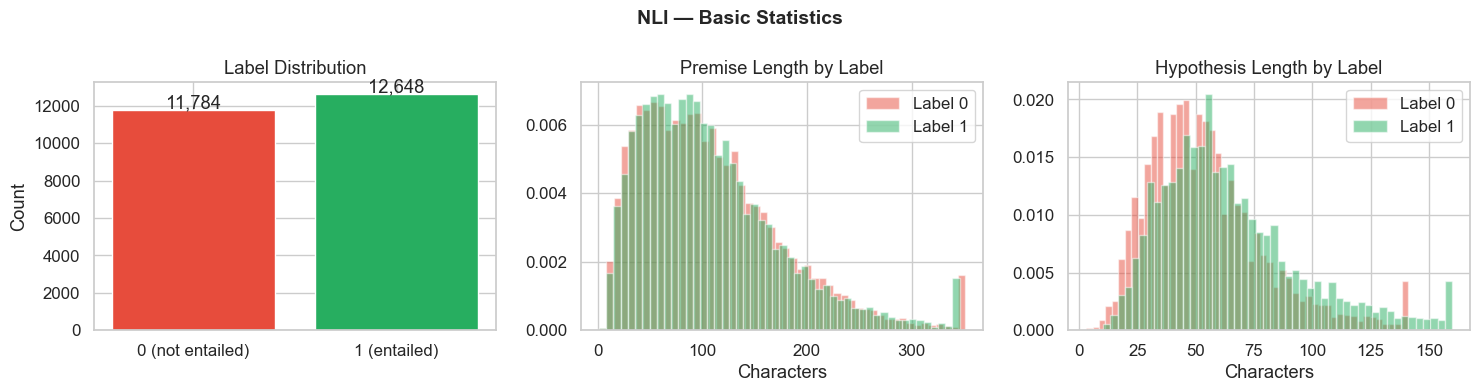

In [5]:
# NLI — label dist
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# label counts
counts = nli_train["label"].value_counts().sort_index()
bars = axes[0].bar(["0 (not entailed)", "1 (entailed)"], counts.values, color=["#e74c3c", "#27ae60"])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 100, f"{v:,}", ha="center")
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")

# premise length by label
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = nli_train[nli_train["label"] == label]["premise"].str.len()
    axes[1].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[1].set_title("Premise Length by Label")
axes[1].set_xlabel("Characters")
axes[1].legend()

# hypothesis length by label
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = nli_train[nli_train["label"] == label]["hypothesis"].str.len()
    axes[2].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[2].set_title("Hypothesis Length by Label")
axes[2].set_xlabel("Characters")
axes[2].legend()

fig.suptitle("NLI — Basic Statistics", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

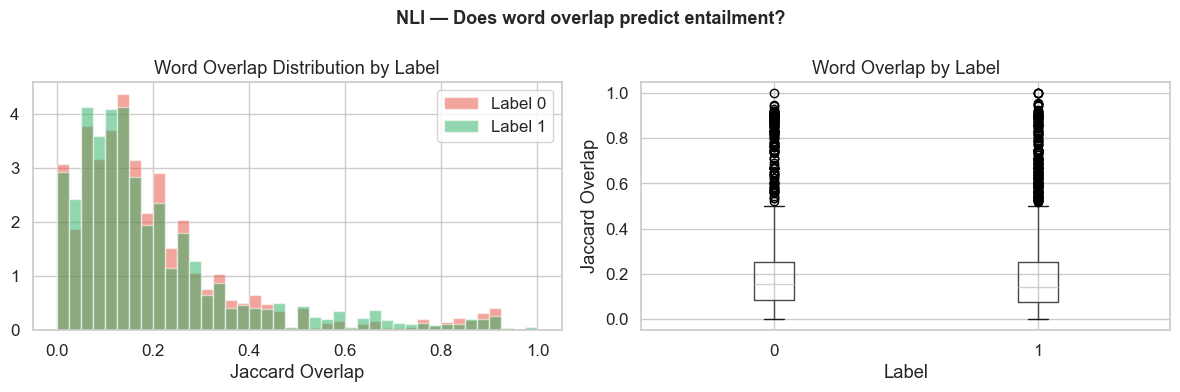

Mean overlap — Label 0: 0.2009
Mean overlap — Label 1: 0.2011


In [6]:
# NLI — Word overlap analysis
# Does lexical overlap between premise and hypothesis correlate with entailment?
nli_sample = nli_train.sample(5000, random_state=42).copy()
nli_sample["overlap"] = nli_sample.apply(lambda r: word_overlap(r["premise"], r["hypothesis"]), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = nli_sample[nli_sample["label"] == label]["overlap"]
    axes[0].hist(subset, bins=40, alpha=0.5, color=color, label=f"Label {label}", density=True, edgecolor="white")
axes[0].set_title("Word Overlap Distribution by Label")
axes[0].set_xlabel("Jaccard Overlap")
axes[0].legend()

# Box plot
nli_sample.boxplot(column="overlap", by="label", ax=axes[1])
axes[1].set_title("Word Overlap by Label")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Jaccard Overlap")
fig.suptitle("NLI — Does word overlap predict entailment?", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Mean overlap — Label 0: {nli_sample[nli_sample['label']==0]['overlap'].mean():.4f}")
print(f"Mean overlap — Label 1: {nli_sample[nli_sample['label']==1]['overlap'].mean():.4f}")

### NLI — Key Observations

- **Balanced dataset** (~48% label 0, ~52% label 1) — quite balanced, might not need stuff in that regard to balance etc
- **Short texts** — premises average ~109 chars, hypotheses ~60 chars → fast training
- **Word overlap** is weak — entailed pairs tend to share slightly more words, but there's massive overlap between the distributions. model can't rely on just word matching

---
## Track B — Evidence Detection (ED)

### What is Evidence Detection? (ai slop answer)

**Evidence Detection** is the task of determining whether a piece of evidence is **relevant** to a given claim:
- A **claim** — a short argumentative statement (e.g., *"We should ban fossil fuels"*)
- A piece of **evidence** — a longer passage that may or may not support/counter the claim

The model predicts whether the evidence is relevant (label = 1) or irrelevant (label = 0).

**Example:**
- Claim: *"We should introduce compulsory voting"*
- Evidence: *"Supporters of compulsory voting argue that it leads to higher voter turnout and greater political legitimacy..."* → **Label 1** (relevant)
- Evidence: *"The price of wheat has risen steadily over the past decade..."* → **Label 0** (irrelevant)

This is an **information retrieval / argument mining** task. The key challenge is the **asymmetry** — claims are very short (~36 chars) while evidence passages are much longer (~202 chars). The model needs to understand topical and argumentative relevance, not just lexical overlap.

In [7]:
# Load ED data
ed_train = pd.read_csv("../data/training_data/ED/train.csv")
ed_dev   = pd.read_csv("../data/training_data/ED/dev.csv")
ed_trial = pd.read_csv("../data/trial_data/ED_trial.csv")

print("=== ED Training Set ===")
summarise(ed_train, "Claim", "Evidence")
print(f"\n=== ED Dev Set ===")
summarise(ed_dev, "Claim", "Evidence")

=== ED Training Set ===
Rows: 21,508
Label balance: {0: 15654, 1: 5854}  (27.2% positive)
Avg Claim length: 36 chars / 5.6 words
Avg Evidence length: 202 chars / 31.1 words

=== ED Dev Set ===
Rows: 5,926
Label balance: {0: 4286, 1: 1640}  (27.7% positive)
Avg Claim length: 36 chars / 5.6 words
Avg Evidence length: 202 chars / 31.2 words


In [8]:
# Show some examples
print("--- Label 0 (Irrelevant Evidence) ---")
for _, row in ed_train[ed_train["label"] == 0].head(3).iterrows():
    print(f"  Claim:    {row['Claim'][:100]}")
    print(f"  Evidence: {row['Evidence'][:150]}")
    print()

print("--- Label 1 (Relevant Evidence) ---")
for _, row in ed_train[ed_train["label"] == 1].head(3).iterrows():
    print(f"  Claim:    {row['Claim'][:100]}")
    print(f"  Evidence: {row['Evidence'][:150]}")
    print()

--- Label 0 (Irrelevant Evidence) ---
  Claim:    We should introduce school vouchers
  Evidence: Among the many educational reform efforts, such as charter schools, school vouchers, magnet schools, and alternative schools, the full-service communi

  Claim:    We should legalize insider trading
  Evidence: The U.S. Securities and Exchange Commission was established the following year, which helped combat insider trading and reducing transaction risk.  

  Claim:    We should subsidize investigative journalism
  Evidence: The film won an Emmy Award (1980), George Polk Award[REF] for investigative journalism on TV, Hugh M. Hefner First Amendment Award,[REF] and Best Docu

--- Label 1 (Relevant Evidence) ---
  Claim:    We should further exploit nuclear power
  Evidence: a 2001 survey by the European Commission found that "only 10.1 percent of Europeans trusted the nuclear industry

  Claim:    Sex education should be mandatory
  Evidence: Virginity pledges and sexual abstinence educatio

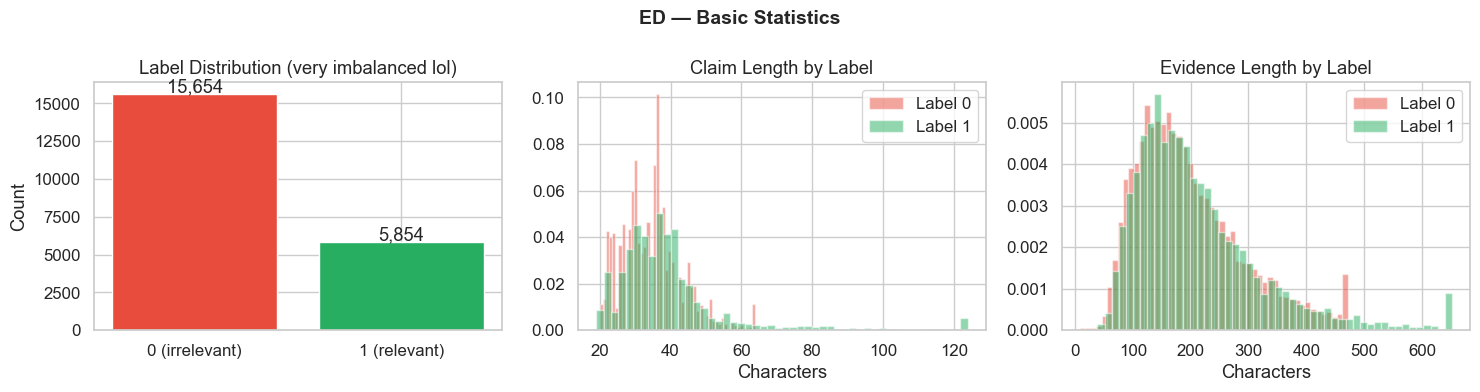

In [9]:
# ED — Label distribution & text lengths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# label counts
counts = ed_train["label"].value_counts().sort_index()
bars = axes[0].bar(["0 (irrelevant)", "1 (relevant)"], counts.values, color=["#e74c3c", "#27ae60"])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 100, f"{v:,}", ha="center")
axes[0].set_title("Label Distribution (very imbalanced lol)")
axes[0].set_ylabel("Count")

# claim length
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = ed_train[ed_train["label"] == label]["Claim"].str.len()
    axes[1].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[1].set_title("Claim Length by Label")
axes[1].set_xlabel("Characters")
axes[1].legend()

# evidence length
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = ed_train[ed_train["label"] == label]["Evidence"].str.len()
    axes[2].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[2].set_title("Evidence Length by Label")
axes[2].set_xlabel("Characters")
axes[2].legend()

fig.suptitle("ED — Basic Statistics", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

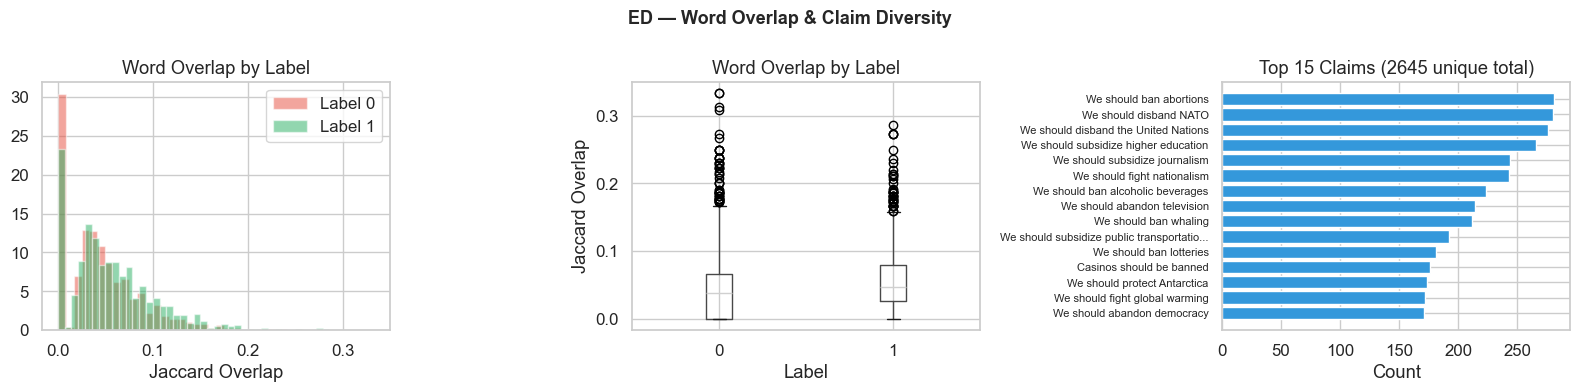

Mean overlap — Label 0: 0.0457
Mean overlap — Label 1: 0.0567
Unique claims: 2645


In [10]:
# ED — Word overlap and claim diversity
ed_sample = ed_train.sample(5000, random_state=42).copy()
ed_sample["overlap"] = ed_sample.apply(lambda r: word_overlap(r["Claim"], r["Evidence"]), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# overlap
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = ed_sample[ed_sample["label"] == label]["overlap"]
    axes[0].hist(subset, bins=40, alpha=0.5, color=color, label=f"Label {label}", density=True, edgecolor="white")
axes[0].set_title("Word Overlap by Label")
axes[0].set_xlabel("Jaccard Overlap")
axes[0].legend()

# Box plot
ed_sample.boxplot(column="overlap", by="label", ax=axes[1])
axes[1].set_title("Word Overlap by Label")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Jaccard Overlap")

# unique claims
unique_claims = ed_train["Claim"].nunique()
claim_counts = ed_train["Claim"].value_counts().head(15)
axes[2].barh(range(len(claim_counts)), claim_counts.values, color="#3498db")
axes[2].set_yticks(range(len(claim_counts)))
axes[2].set_yticklabels([c[:40] + "..." if len(c) > 40 else c for c in claim_counts.index], fontsize=8)
axes[2].set_title(f"Top 15 Claims ({unique_claims} unique total)")
axes[2].set_xlabel("Count")
axes[2].invert_yaxis()

fig.suptitle("ED — Word Overlap & Claim Diversity", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Mean overlap — Label 0: {ed_sample[ed_sample['label']==0]['overlap'].mean():.4f}")
print(f"Mean overlap — Label 1: {ed_sample[ed_sample['label']==1]['overlap'].mean():.4f}")
print(f"Unique claims: {unique_claims}")

### ED — Key Observations

- **Heavily imbalanced** — 73% negative (irrelevant), 27% positive (relevant). prob class weights, oversampling, F1-focused training aka lot of work 
- **Strong asymmetry** — claims are very short (~36 chars) vs evidence (~202 chars). The model needs to learn to "query" the evidence with the claim
- **Word overlap is useful here** — relevant evidence tends to share more words with the claim (makes sense). A TF-IDF baseline could be good
- **Repeated claims** — the same claim appears with many different evidence passages. This means the model might learn claim-specific biases

---
## Track C — Authorship Verification (AV)

### What is Authorship Verification? (ai slop answer)

**Authorship Verification** is the task of determining whether two texts were written by the **same author**:
- **text_1** — a passage written by some author
- **text_2** — another passage that may or may not be by the same author

The model predicts same author (label = 1) or different authors (label = 0).

**What makes this fundamentally different from NLI/ED:**

Unlike NLI and ED, the answer has **nothing to do with the content or meaning** of the text. Two texts about the same topic could be by different authors, and two texts about completely different topics could be by the same author. What matters is **writing style**:
- Vocabulary preferences and richness
- Sentence structure and length patterns
- Punctuation habits
- Function word usage (the, and, but, however...)
- Character-level patterns (contractions, capitalization)

This is the domain of **stylometry** — a field with decades of research predating modern NLP. It's famously been used in forensic linguistics (identifying anonymous authors) and literary analysis (e.g., disputed Shakespeare authorship).

In [11]:
# Load AV data
av_train = pd.read_csv("../data/training_data/AV/train.csv")
av_dev   = pd.read_csv("../data/training_data/AV/dev.csv")
av_trial = pd.read_csv("../data/trial_data/AV_trial.csv")

print("=== AV Training Set ===")
summarise(av_train, "text_1", "text_2")
print(f"\n=== AV Dev Set ===")
summarise(av_dev, "text_1", "text_2")

=== AV Training Set ===
Rows: 27,643
Label balance: {0.0: 13950, 1.0: 13693}  (49.5% positive)
Avg text_1 length: 577 chars / 100.3 words
Avg text_2 length: 578 chars / 100.7 words

=== AV Dev Set ===
Rows: 5,993
Label balance: {1: 3056, 0: 2937}  (51.0% positive)
Avg text_1 length: 577 chars / 100.5 words
Avg text_2 length: 579 chars / 100.8 words


In [12]:
# Show some examples
print("--- Label 0 (Different Authors) ---")
for _, row in av_train[av_train["label"] == 0].head(2).iterrows():
    print(f"  text_1: {str(row['text_1'])[:200]}")
    print(f"  text_2: {str(row['text_2'])[:200]}")
    print()

print("--- Label 1 (Same Author) ---")
for _, row in av_train[av_train["label"] == 1].head(2).iterrows():
    print(f"  text_1: {str(row['text_1'])[:200]}")
    print(f"  text_2: {str(row['text_2'])[:200]}")
    print()

--- Label 0 (Different Authors) ---
  text_1: halloween with kids is fun - getting them to bed - not so much. :)
  text_2: Something new for Tuesdays (yes, I know it's Friday!): urlLink Top Ten Brand Names You're Loyal To 1. Target 2. urlLink H-E-B 3. Coca-Cola 4. Charmin 5. Aveeno 6. Pepto-Bismol 7. Honda 8. Starbucks 9.

  text_1: everybody sing! urlLink http://www.smokeybear.com/vault/name_song.asp
  text_2: Good lord, Skee. The man has voices talking to him, and that's no joke. Like, does he do that thing with his hands? You know? I think he's trying to bat away demons or something. And he has this volum

--- Label 1 (Same Author) ---
  text_1: 'The preservation of health is a duty. Few seem conscious that there is such a thing as physical morality.' -- Herbert Spencer
  text_2: Introversion urlLink Andrew has an interesting post about introversion.

  text_1: Marybeth: The call's ended and I'll be available for the 2:30 call. Best, Jeff
  text_2: FYI. Just got a call from Jan Smut

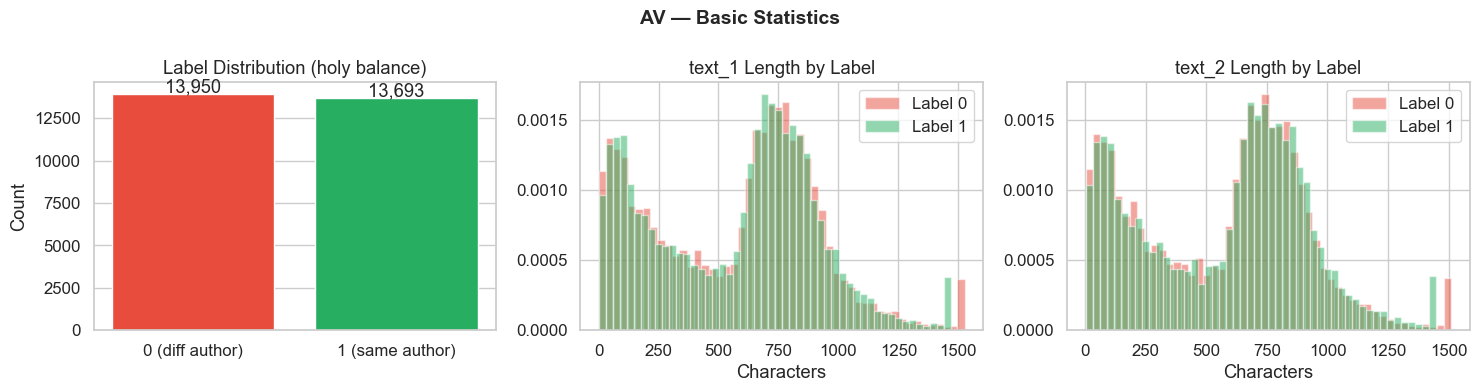

In [13]:
# AV — Label distribution & text lengths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# label counts
counts = av_train["label"].value_counts().sort_index()
bars = axes[0].bar(["0 (diff author)", "1 (same author)"], counts.values, color=["#e74c3c", "#27ae60"])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 100, f"{v:,}", ha="center")
axes[0].set_title("Label Distribution (holy balance)")
axes[0].set_ylabel("Count")

# text_1 length by label
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = av_train[av_train["label"] == label]["text_1"].str.len()
    axes[1].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[1].set_title("text_1 Length by Label")
axes[1].set_xlabel("Characters")
axes[1].legend()

# text_2 length by label
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = av_train[av_train["label"] == label]["text_2"].str.len()
    axes[2].hist(subset.clip(upper=subset.quantile(0.99)), bins=50, alpha=0.5, color=color,
                 label=f"Label {label}", density=True, edgecolor="white")
axes[2].set_title("text_2 Length by Label")
axes[2].set_xlabel("Characters")
axes[2].legend()

fig.suptitle("AV — Basic Statistics", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

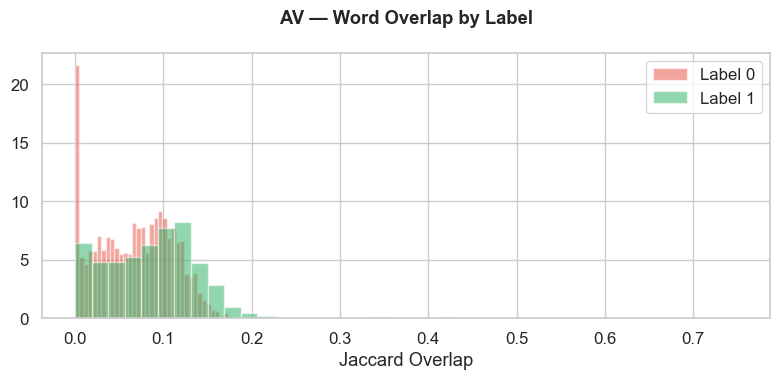

Mean overlap — Label 0: 0.0672
Mean overlap — Label 1: 0.0887


In [14]:
# AV — Word overlap
av_sample = av_train.sample(5000, random_state=42).copy()
av_sample["overlap"] = av_sample.apply(lambda r: word_overlap(r["text_1"], r["text_2"]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
    subset = av_sample[av_sample["label"] == label]["overlap"]
    ax.hist(subset, bins=40, alpha=0.5, color=color, label=f"Label {label}", density=True, edgecolor="white")
ax.set_title("AV — Word Overlap by Label\n", fontweight="bold")
ax.set_xlabel("Jaccard Overlap")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean overlap — Label 0: {av_sample[av_sample['label']==0]['overlap'].mean():.4f}")
print(f"Mean overlap — Label 1: {av_sample[av_sample['label']==1]['overlap'].mean():.4f}")

### AV — Stylometric Feature Analysis

Since word overlap is useless for AV, let's look at **stylometric features** — measurements of writing style rather than content. The idea: if two texts are by the same author, their style features should be **similar** (small difference), and if by different authors, the style features should **diverge** (large difference).

In [15]:
def stylometric_features(text):
    """Extract basic stylometric features from a single text."""
    text = str(text)
    words = text.split()
    sentences = [s.strip() for s in text.replace("!", ".").replace("?", ".").split(".") if s.strip()]
    return {
        "char_len": len(text),
        "word_count": len(words),
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0,
        "sentence_count": len(sentences),
        "avg_sentence_len": np.mean([len(s.split()) for s in sentences]) if sentences else 0,
        "punctuation_ratio": sum(1 for c in text if c in '.,;:!?-()"\"') / max(len(text), 1),
        "uppercase_ratio": sum(1 for c in text if c.isupper()) / max(len(text), 1),
        "digit_ratio": sum(1 for c in text if c.isdigit()) / max(len(text), 1),
        "unique_word_ratio": len(set(w.lower() for w in words)) / max(len(words), 1),
    }

# Compute |feature(text_1) - feature(text_2)| for each pair
print("Computing stylometric feature differences...")
feat_diffs = []
for _, row in av_sample.iterrows():
    f1 = stylometric_features(row["text_1"])
    f2 = stylometric_features(row["text_2"])
    diff = {f"Δ {k}": abs(f1[k] - f2[k]) for k in f1}
    diff["label"] = row["label"]
    feat_diffs.append(diff)

diff_df = pd.DataFrame(feat_diffs)
print("Done!")

Computing stylometric feature differences...
Done!


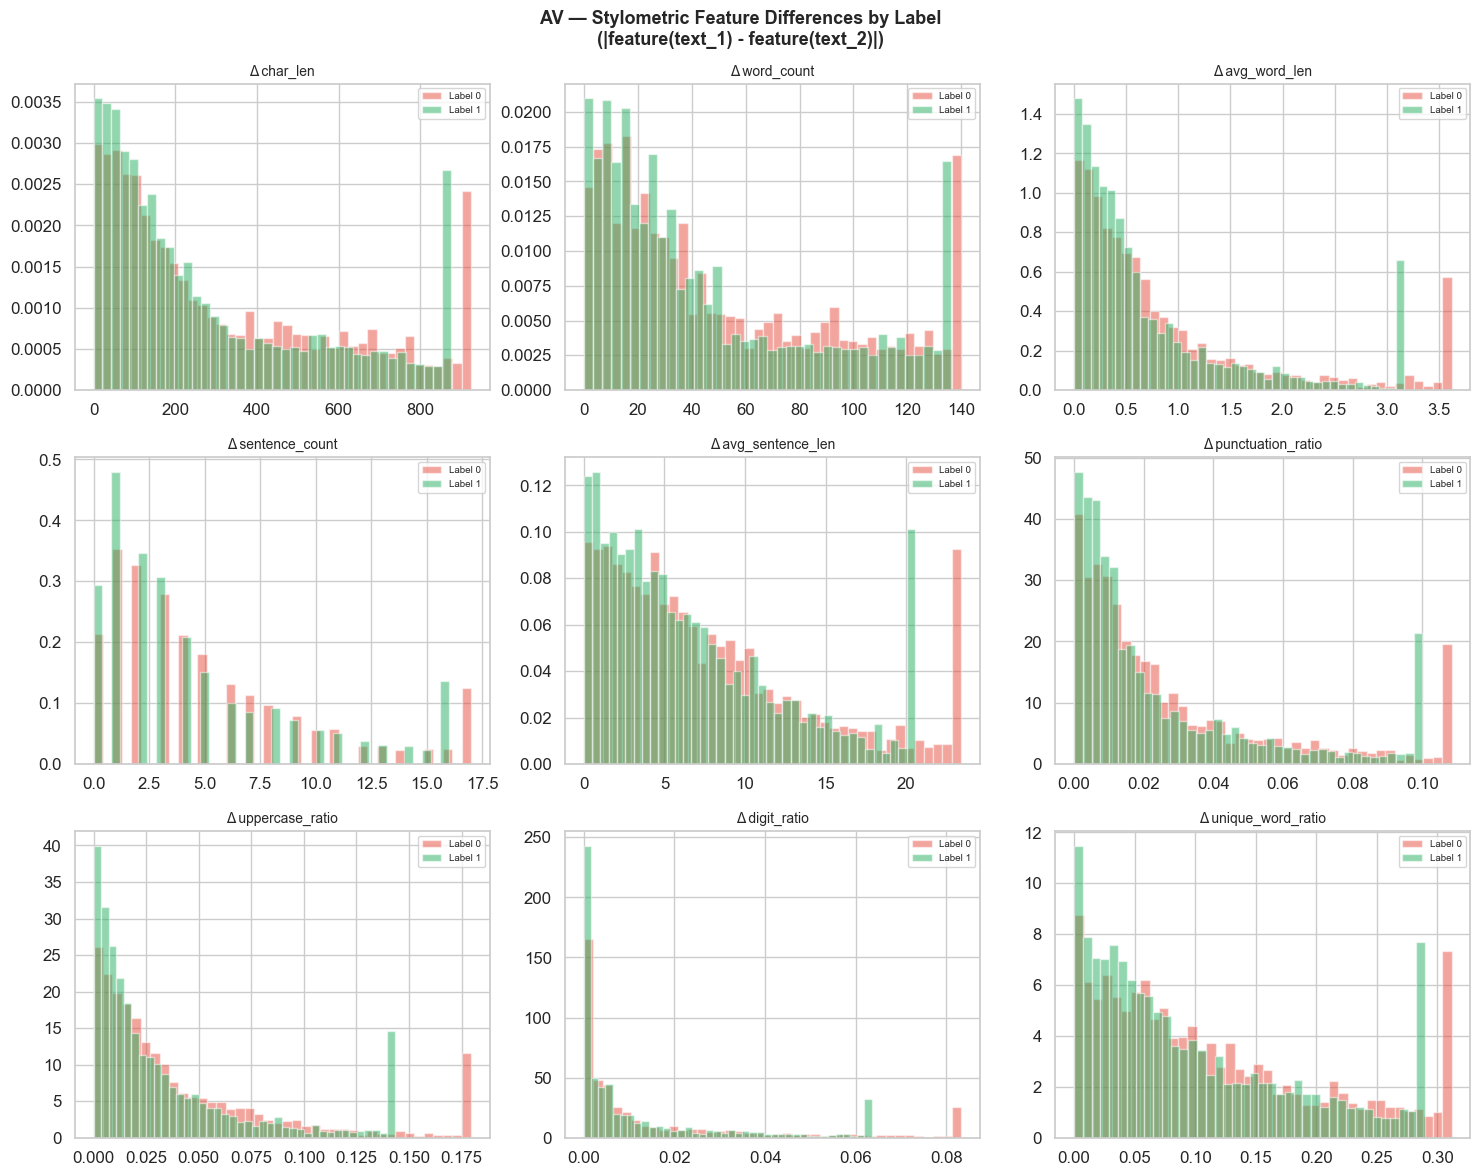

In [16]:
# Plot stylometric feature differences by label
feat_cols = [c for c in diff_df.columns if c != "label"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, feat_cols):
    for label, color in [(0, "#e74c3c"), (1, "#27ae60")]:
        subset = diff_df[diff_df["label"] == label][col]
        clip = subset.quantile(0.95)
        ax.hist(subset.clip(upper=clip), bins=40, alpha=0.5, color=color,
                label=f"Label {label}", density=True, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle("AV — Stylometric Feature Differences by Label\n(|feature(text_1) - feature(text_2)|)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [17]:
# Correlation of feature differences with label
print("Correlation of |Δ feature| with label (AV):")
print("(Negative = same-author pairs have smaller differences)")
print()

corrs = diff_df.corr()["label"].drop("label").sort_values(key=abs, ascending=False)
for name, val in corrs.items():
    bar = "█" * int(abs(val) * 200)
    print(f"  {name:25s} {val:+.4f}  {bar}")

Correlation of |Δ feature| with label (AV):
(Negative = same-author pairs have smaller differences)

  Δ unique_word_ratio       -0.0795  ███████████████
  Δ digit_ratio             -0.0741  ██████████████
  Δ char_len                -0.0665  █████████████
  Δ word_count              -0.0636  ████████████
  Δ uppercase_ratio         -0.0567  ███████████
  Δ avg_sentence_len        -0.0470  █████████
  Δ sentence_count          -0.0444  ████████
  Δ punctuation_ratio       -0.0409  ████████
  Δ avg_word_len            -0.0203  ████


### AV — Key Observations

- **Perfectly balanced** — ~50/50 split, no class-weight needed
- **Long texts** — average ~577 chars each (about 100+ words). More text = richer stylometric signal
- **Word overlap is techically useless** — content similarity doesn't predict authorship but could in theory show author writing style because they may like to repeat certain words
- **Stylometric feature differences show weak but consistent signals:**
  - All correlations are negative — meaning same-author pairs have *smaller* style differences (correct direction!)
  - `unique_word_ratio` and `digit_ratio` are the strongest individual features
  - But individual correlations are weak (< 0.08) — you need to **combine many features** or use more sophisticated features (char n-grams, function word profiles, POS distributions) for a strong Cat A solution
- **This is the most distinctive task** — it requires a fundamentally different approach (style vs content), making it the most interesting for creativity marks

---
## Summary Comparison

| | **NLI** | **ED** | **AV** |
|---|---|---|---|
| **Task essence** | Semantic entailment | Topical relevance | Writing style matching |
| **Balance** | ✅ Balanced | ⚠️ 73/27 imbalanced | ✅ Balanced |
| **Text lengths** | Short (109/60) | Asymmetric (36/202) | Long (577/578) |
| **Word overlap useful?** | Slightly | Yes | No |
| **Cat A potential** | Moderate | Moderate | High (stylometry) |
| **Cat B potential** | High (sentence embeddings) | High (bi-encoder) | Moderate (style embeddings) |
| **Cat C potential** | Very High (BERT/RoBERTa) | High (cross-encoder) | High (Longformer/style-LM) |
| **Creativity room** | Low (well-studied) | Medium | High (unique task) |
| **Literature** | Very large | Growing | Rich (stylometry) |